In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
file_path = r"E:\aditi_eeg\visual_eeg\tbi\p1_a_2026-04-06_11-17-23_Segment_0.edf"

raw = mne.io.read_raw_edf(file_path, preload=True)
raw.info

Extracting EDF parameters from E:\aditi_eeg\visual_eeg\tbi\p1_a_2026-04-06_11-17-23_Segment_0.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 204799  =      0.000 ...   199.999 secs...


<Info | 8 non-empty values
 bads: []
 ch_names: EEG FC5-CPz, EEG FC1-CPz, EEG FC2-CPz, EEG FC6-CPz, EEG M1-CPz, ...
 chs: 56 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 512.0 Hz
 meas_date: 2026-04-06 11:17:24 UTC
 nchan: 56
 projs: []
 sfreq: 1024.0 Hz
 subject_info: 3 items (dict)
>

In [3]:
print(raw.ch_names)

['EEG FC5-CPz', 'EEG FC1-CPz', 'EEG FC2-CPz', 'EEG FC6-CPz', 'EEG M1-CPz', 'EEG T7-CPz', 'EEG C3-CPz', 'EEG Cz-CPz', 'EEG C4-CPz', 'EEG T8-CPz', 'EEG M2-CPz', 'EEG CP5-CPz', 'EEG CP1-CPz', 'EEG CP2-CPz', 'EEG CP6-CPz', 'EEG P7-CPz', 'EEG P3-CPz', 'EEG Pz-CPz', 'EEG P4-CPz', 'EEG P8-CPz', 'EEG POz-CPz', 'EEG O1-CPz', 'EEG O2-CPz', 'EEG EOG-CPz', 'EEG AF7-CPz', 'EEG AF3-CPz', 'EEG AF4-CPz', 'EEG AF8-CPz', 'EEG F5-CPz', 'EEG F1-CPz', 'EEG F2-CPz', 'EEG F6-CPz', 'EEG FC3-CPz', 'EEG FCz-CPz', 'EEG FC4-CPz', 'EEG C5-CPz', 'EEG C1-CPz', 'EEG C2-CPz', 'EEG C6-CPz', 'EEG CP3-CPz', 'EEG CP4-CPz', 'EEG P5-CPz', 'EEG P1-CPz', 'EEG P2-CPz', 'EEG P6-CPz', 'EEG PO5-CPz', 'EEG PO3-CPz', 'EEG PO4-CPz', 'EEG PO6-CPz', 'EEG FT7-CPz', 'EEG FT8-CPz', 'EEG TP7-CPz', 'EEG TP8-CPz', 'EEG PO7-CPz', 'EEG PO8-CPz', 'EEG Oz-CPz']


In [4]:
mapping = {}
for ch in raw.ch_names:
    new_name = ch.replace('EEG ', '').replace('-CPz', '').strip()
    mapping[ch] = new_name

raw.rename_channels(mapping)

<RawEDF | p1_a_2026-04-06_11-17-23_Segment_0.edf, 56 x 204800 (200.0 s), ~87.6 MB, data loaded>

In [5]:
important_channels = [
    'Fz', 'Cz', 'Pz',   # ⭐ MOST IMPORTANT (P300)
    'P3', 'P4',
    'C3', 'C4',
    'O1', 'O2'
]

selected = [ch for ch in important_channels if ch in raw.ch_names]

raw.pick(selected)

<RawEDF | p1_a_2026-04-06_11-17-23_Segment_0.edf, 8 x 204800 (200.0 s), ~12.5 MB, data loaded>

Extracting EDF parameters from E:\aditi_eeg\visual_eeg\tbi\p7_visual_2026-04-06_12-59-46_Segment_0.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 228351  =      0.000 ...   222.999 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Available Channels: ['FC5', 'FC1', 'FC2', 'FC6', 'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6', 'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'O2', 'EOG', 'AF7', 'AF3', 'AF4', 'AF8', 'F5', 'F1', 'F2', 'F6', 'FC3', 'FCz', 'FC4', 'C5', 'C1', 'C2', 'C6', 'CP3', 'CP4', 'P5', 'P1', 'P2', 'P6', 'PO5', 'PO3', 'PO4', 'PO6', 'FT7', 'FT8', 'TP7', 'TP8', 'PO7', 'PO8', 'Oz']
Using Channels: ['Cz', 'Pz', 'P3', 'P4', 'C3', 'C4', 'O1', 'O2']
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (

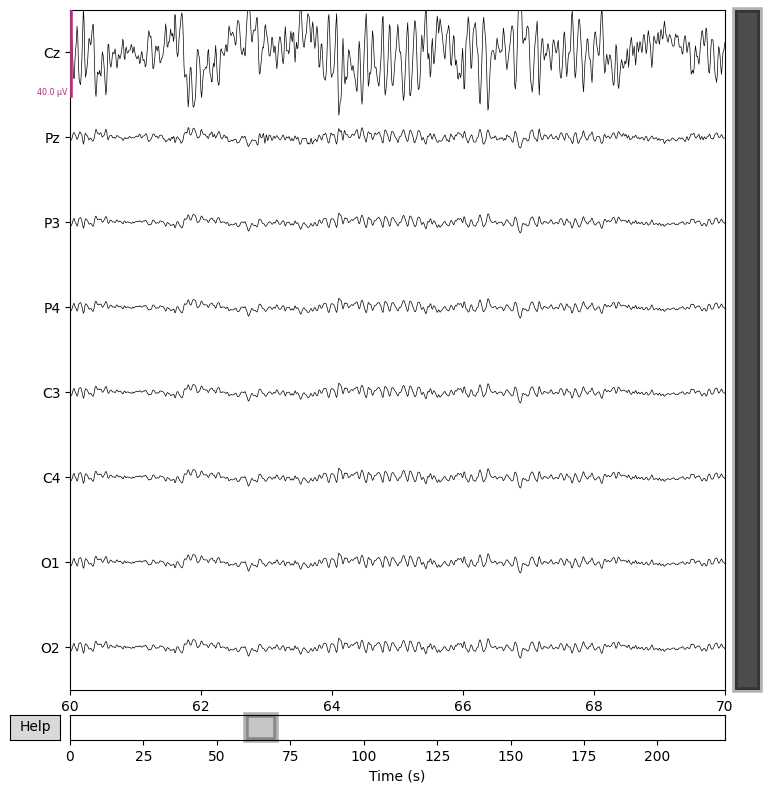

In [6]:
import mne

def plot_clean_eeg(file_path, start_time=60):
    raw = mne.io.read_raw_edf(file_path, preload=True)
    
    raw.pick_types(eeg=True)
    
    # 🔥 Fix channel names
    mapping = {}
    for ch in raw.ch_names:
        new_name = ch.replace('EEG ', '').replace('-CPz', '').strip()
        mapping[ch] = new_name
    raw.rename_channels(mapping)
    
    print("Available Channels:", raw.ch_names)
    
    # 🔥 Select important channels
    important_channels = ['Fz','Cz','Pz','P3','P4','C3','C4','O1','O2']
    selected = [ch for ch in important_channels if ch in raw.ch_names]
    
    print("Using Channels:", selected)
    
    raw.pick(selected)
    
    # Preprocessing
    raw.filter(0.1, 30)
    raw.notch_filter(50)
    raw.set_eeg_reference('average')
    raw.set_annotations(None)
    
    # Plot
    raw.plot(
        start=start_time,
        duration=10,
        n_channels=len(selected),
        title="Clean EEG (Important Channels Only)"
    )

# Run
plot_clean_eeg(r"E:\aditi_eeg\visual_eeg\tbi\p7_visual_2026-04-06_12-59-46_Segment_0.edf")

Extracting EDF parameters from E:\aditi_eeg\visual_eeg\non_tbi\p2_visual_2026-04-06_12-14-22_Segment_0.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 233471  =      0.000 ...   227.999 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Using Channels: ['Pz', 'Cz', 'FCz', 'AF7', 'AF8']
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 33793 samples (33.001 s)

Filtering raw data in 1 contiguous segment
Setting up band

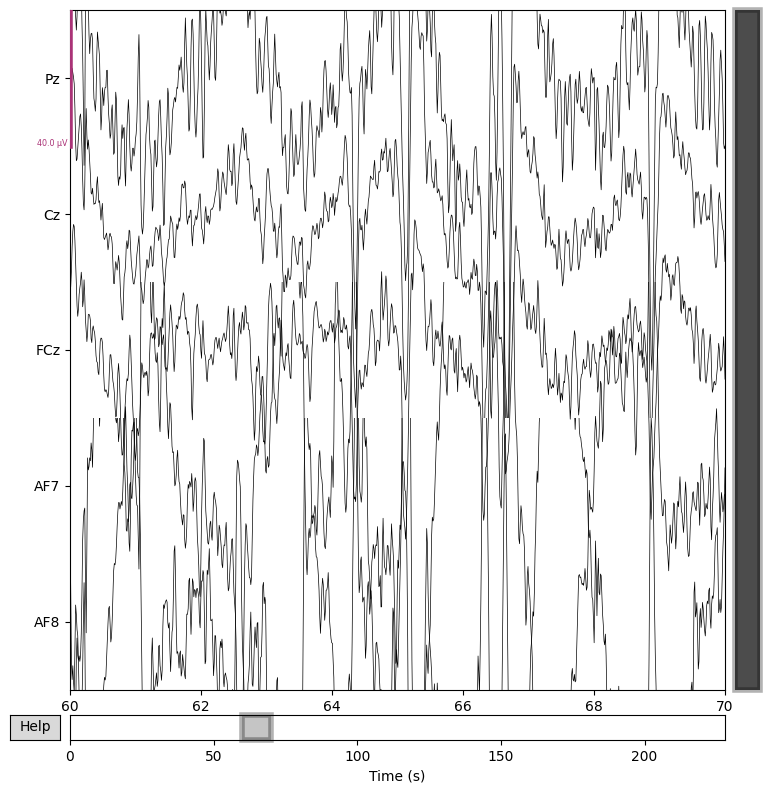

In [7]:
import mne

def plot_custom_eeg(file_path, start_time=60):
    raw = mne.io.read_raw_edf(file_path, preload=True)
    
    # Keep only EEG
    raw.pick_types(eeg=True)
    
    # 🔥 Fix channel names
    mapping = {}
    for ch in raw.ch_names:
        new_name = ch.replace('EEG ', '').replace('-CPz', '').strip()
        mapping[ch] = new_name
    raw.rename_channels(mapping)
    
    # ✅ Your selected channels
    my_channels = [
        'AFz', 'Pz', 'CPz', 'Cz', 'FCz', 'Fz',
        'Fp1', 'Fp2', 'AF7', 'AF8', 'F7', 'F8'
    ]
    
    # Keep only available channels
    selected = [ch for ch in my_channels if ch in raw.ch_names]
    
    print("Using Channels:", selected)
    
    raw.pick(selected)
    
    # Preprocessing
    raw.filter(0.1, 30)
    raw.notch_filter(50)
    raw.set_eeg_reference('average')
    raw.set_annotations(None)
    
    # Plot continuous EEG
    raw.plot(
        start=start_time,
        duration=10,
        n_channels=len(selected),
        title="Custom EEG Channels (Continuous)"
    )

# Example
plot_custom_eeg(
    r"E:\aditi_eeg\visual_eeg\non_tbi\p2_visual_2026-04-06_12-14-22_Segment_0.edf",
    start_time=60
)

Extracting EDF parameters from E:\aditi_eeg\visual_eeg\non_tbi\p2_visual_2026-04-06_12-14-22_Segment_0.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 233471  =      0.000 ...   227.999 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Using Channels: ['FCz', 'Cz', 'Pz', 'AF7', 'AF8']
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 33793 samples (33.001 s)

Filtering raw data in 1 contiguous segment
Setting up band

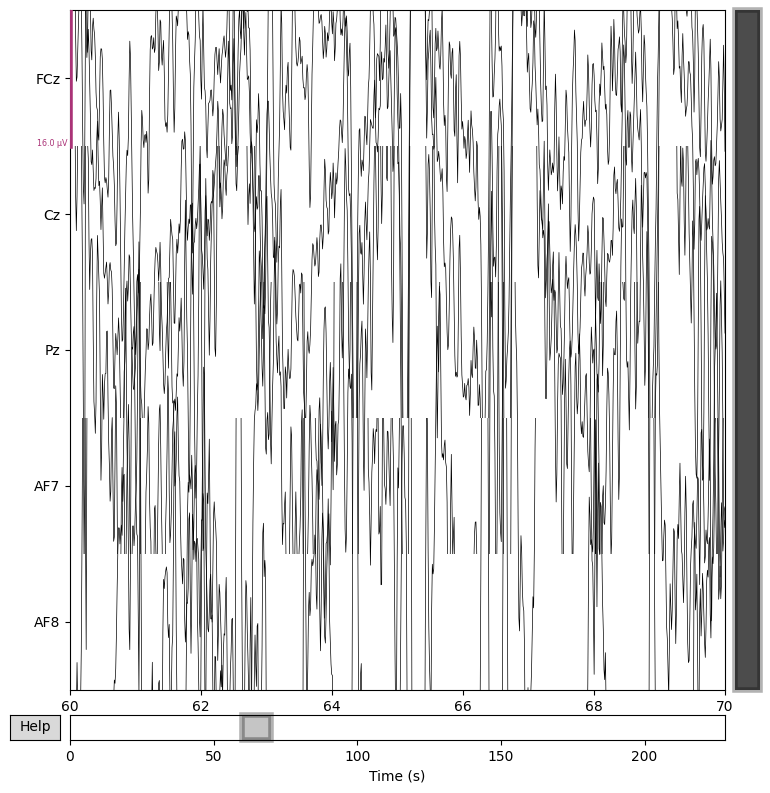

In [8]:
import mne

def plot_final_eeg(file_path, start_time=60):
    raw = mne.io.read_raw_edf(file_path, preload=True)
    
    # Keep EEG only
    raw.pick_types(eeg=True)
    
    # 🔥 Fix channel names
    mapping = {}
    for ch in raw.ch_names:
        new_name = ch.replace('EEG ', '').replace('-CPz', '').strip()
        mapping[ch] = new_name
    raw.rename_channels(mapping)
    
    # ✅ YOUR CHANNELS (same as you selected)
    my_channels = [
        'AFz','Fz','FCz','Cz','CPz','Pz',
        'Fp1','Fp2','AF7','AF8','F7','F8'
    ]
    
    selected = [ch for ch in my_channels if ch in raw.ch_names]
    raw.pick(selected)
    
    print("Using Channels:", selected)
    
    # Preprocessing
    raw.filter(0.1, 30)
    raw.notch_filter(50)
    raw.set_eeg_reference('average')
    raw.set_annotations(None)
    
    # 🔥 PERFECT VIEW SETTINGS
    raw.plot(
        start=start_time,
        duration=10,                  # 👈 long waves
        n_channels=len(selected),     # 👈 all your channels
        scalings=dict(eeg=8e-6),      # 👈 compact (chota)
        title="Final EEG View (Clean + Long)"
    )

# Run
plot_final_eeg(
    r"E:\aditi_eeg\visual_eeg\non_tbi\p2_visual_2026-04-06_12-14-22_Segment_0.edf",
    start_time=60
)

In [9]:
import mne

def preprocess_and_plot(file_path, start_time=60):
    # Load EEG
    raw = mne.io.read_raw_edf(file_path, preload=True)
    
    # Keep only EEG channels
    raw.pick_types(eeg=True)
    
    # 🔥 Fix channel names (EEG FC5-CPz → FC5)
    mapping = {}
    for ch in raw.ch_names:
        new_name = ch.replace('EEG ', '').replace('-CPz', '').strip()
        mapping[ch] = new_name
    raw.rename_channels(mapping)
    
    # ✅ Select your important channels
    my_channels = [
        'AFz','Fz','FCz','Cz','CPz','Pz',
        'Fp1','Fp2','AF7','AF8','F7','F8'
    ]
    
    selected = [ch for ch in my_channels if ch in raw.ch_names]
    raw.pick(selected)
    
    print("Using Channels:", selected)
    
    # 🔥 PREPROCESSING
    
    # 1. Bandpass filter (remove noise)
    raw.filter(0.1, 30)
    
    # 2. Notch filter (remove powerline noise)
    raw.notch_filter(50)
    
    # 3. Referencing (stabilize signal)
    raw.set_eeg_reference('average')
    
    # 4. Remove event markers (clean view)
    raw.set_annotations(None)
    
    # 🔥 VISUALIZATION (clean + clear)
    fig = raw.plot(
    start=60,
    duration=25,
    n_channels=len(selected),
    scalings=dict(eeg=5e-6)
)

fig.canvas.manager.full_screen_toggle()

# Run
preprocess_and_plot(
    r"E:\aditi_eeg\visual_eeg\tbi\p1_a_2026-04-06_11-17-23_Segment_0.edf",
    start_time=60
)

NameError: name 'fig' is not defined

Extracting EDF parameters from E:\aditi_eeg\visual_eeg\tbi\p1_a_2026-04-06_11-17-23_Segment_0.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 204799  =      0.000 ...   199.999 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Using Channels: ['Cz', 'Pz']
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 33793 samples (33.001 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz



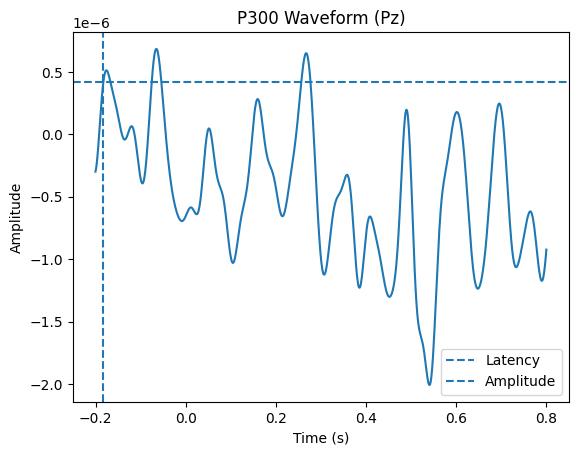

Effective window size : 2.000 (s)
Plotting power spectral density (dB=True).


C:\Users\HP\AppData\Local\Temp\ipykernel_244876\360191057.py:86: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psd.plot()
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


(4.2024628933505463e-07, -0.1826171875)

In [10]:
import mne
import numpy as np
import matplotlib.pyplot as plt

def p300_features(file_path):
    
    # Load EEG
    raw = mne.io.read_raw_edf(file_path, preload=True)
    raw.pick_types(eeg=True)
    
    # 🔥 Fix channel names
    mapping = {}
    for ch in raw.ch_names:
        new_name = ch.replace('EEG ', '').replace('-CPz', '').strip()
        mapping[ch] = new_name
    raw.rename_channels(mapping)
    
    # Select important channels (P300 focused)
    channels = ['Fz','Cz','Pz']
    selected = [ch for ch in channels if ch in raw.ch_names]
    raw.pick(selected)
    
    print("Using Channels:", selected)
    
    # Preprocessing
    raw.filter(0.1, 30)
    raw.notch_filter(50)
    raw.set_eeg_reference('average')
    
    # 🔥 EVENTS → needed for P300
    events, event_id = mne.events_from_annotations(raw)
    
    # Epochs
    epochs = mne.Epochs(
    raw,
    events,
    event_id=event_id,
    tmin=-0.2,
    tmax=0.8,
    baseline=(None, 0),
    preload=True,
    event_repeated='merge'   # 🔥 FIX HERE
)
    
    # Select target events (P300 appears here)
    target_key = [k for k in event_id.keys() if "target" in k.lower()][0]
    
    evoked = epochs[target_key].average()
    
    # 🔥 P300 from Pz (best channel)
    if 'Pz' in evoked.ch_names:
        idx = evoked.ch_names.index('Pz')
        signal = evoked.data[idx]
        times = evoked.times
        
        # Amplitude & Latency
        # Only look between 0.25 to 0.5 sec
        mask = (times >= 0.25) & (times <= 0.5)

        signal_window = signal[mask]
        times_window = times[mask]

        peak_idx = np.argmax(signal_window)

        amp = signal_window[peak_idx]
        lat = times_window[peak_idx]
        amp = signal[peak_idx]
        lat = times[peak_idx]
        
        print(f"P300 Amplitude: {amp}")
        print(f"P300 Latency: {lat} sec")
        
        # Plot P300
        plt.figure()
        plt.plot(times, signal)
        plt.axvline(lat, linestyle='--', label="Latency")
        plt.axhline(amp, linestyle='--', label="Amplitude")
        plt.title("P300 Waveform (Pz)")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.show()
    
    # 🔥 PSD (Frequency Analysis)
    psd = raw.compute_psd(fmin=0.1, fmax=30)
    psd.plot()
    
    return amp, lat

# Run
p300_features(r"E:\aditi_eeg\visual_eeg\tbi\p1_a_2026-04-06_11-17-23_Segment_0.edf")

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 2.000 (s)
Plotting power spectral density (dB=True).


C:\Users\HP\AppData\Local\Temp\ipykernel_244876\3972374008.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.plot_psd(fmin=0.1, fmax=40)
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


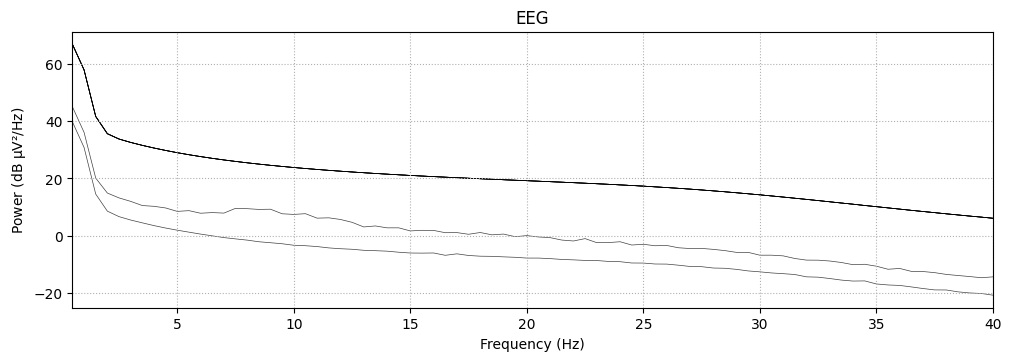

In [11]:
raw.plot_psd(fmin=0.1, fmax=40)

In [12]:
# Bandpass filter
raw.filter(0.1, 30)

# Notch filter
raw.notch_filter(50)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 33793 samples (33.001 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband 

<RawEDF | p1_a_2026-04-06_11-17-23_Segment_0.edf, 8 x 204800 (200.0 s), ~12.5 MB, data loaded>

In [13]:
def clean_channel_names(raw):
    new_names = {}
    
    for ch in raw.ch_names:
        new_name = ch
        
        # Remove 'EEG '
        new_name = new_name.replace('EEG ', '')
        
        # Remove reference '-CPz'
        new_name = new_name.replace('-CPz', '')
        
        new_names[ch] = new_name
    
    raw.rename_channels(new_names)
    return raw


raw = clean_channel_names(raw)

print(raw.ch_names[:10])  # check

['Cz', 'Pz', 'P3', 'P4', 'C3', 'C4', 'O1', 'O2']


In [14]:
raw.set_channel_types({'EOG': 'eog'})

ValueError: This channel name (EOG) doesn't exist in info.

In [15]:
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage)

<RawEDF | p1_a_2026-04-06_11-17-23_Segment_0.edf, 8 x 204800 (200.0 s), ~12.5 MB, data loaded>

Extracting EDF parameters from E:\aditi_eeg\visual_eeg\tbi\p1_a_2026-04-06_11-17-23_Segment_0.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 204799  =      0.000 ...   199.999 secs...
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 33793 samples (33.001 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Fitting ICA to data using 55 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 5.1s.


C:\Users\HP\AppData\Local\Temp\ipykernel_244876\409240855.py:22: RuntimeWarning: Using n_components=15 (resulting in n_components_=15) may lead to an unstable mixing matrix estimation because the ratio between the largest (44) and smallest (1.6e-30) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 10
  ica.fit(raw)


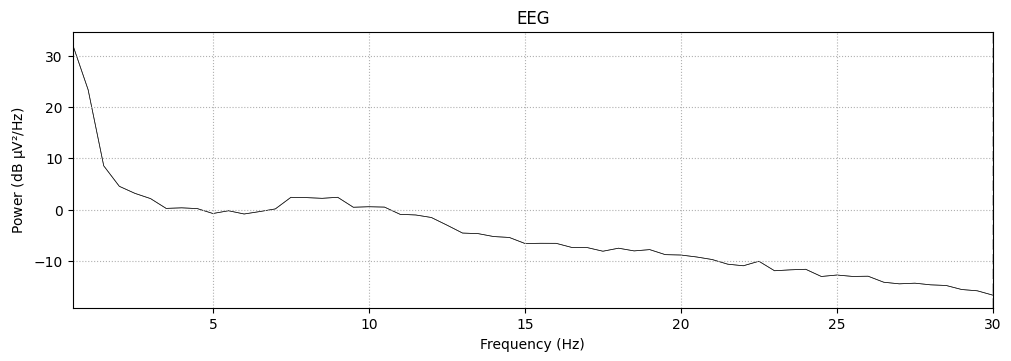

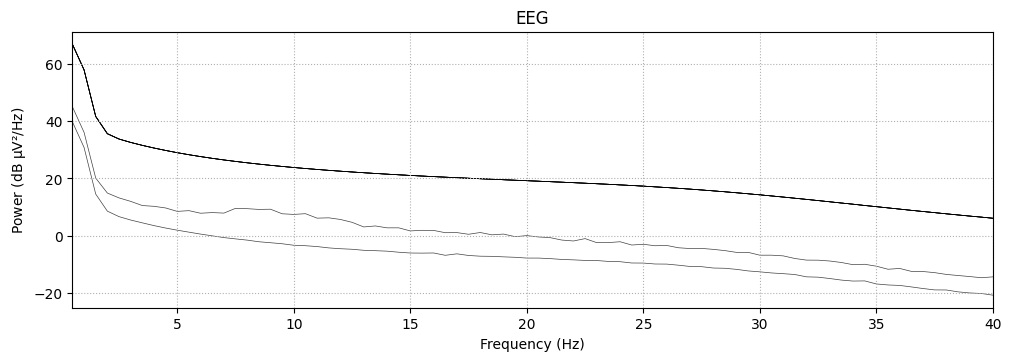

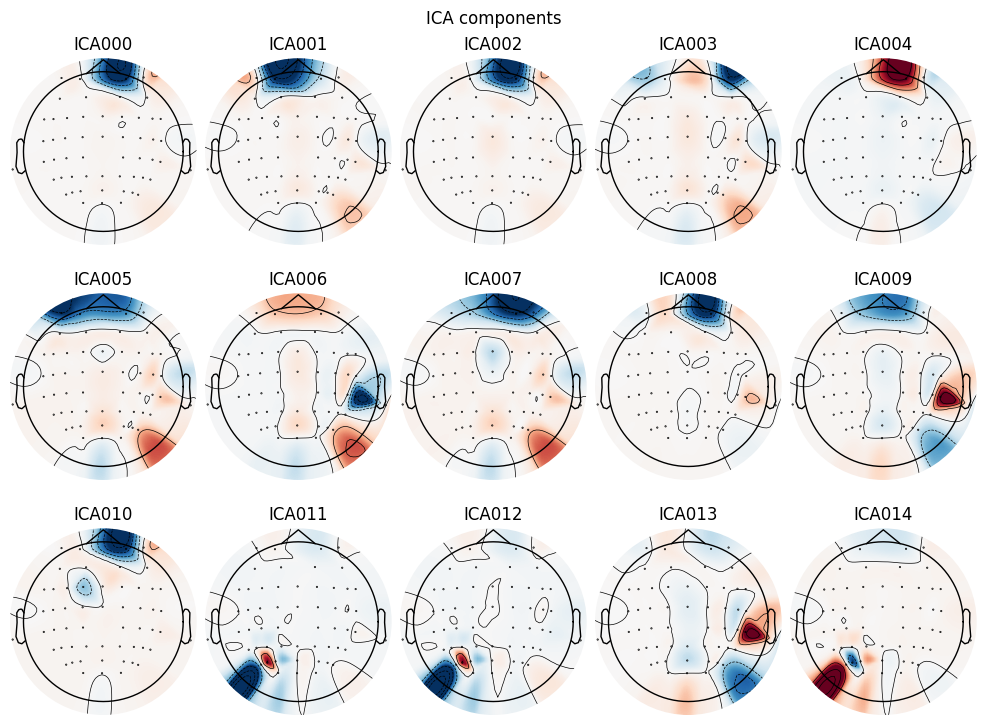

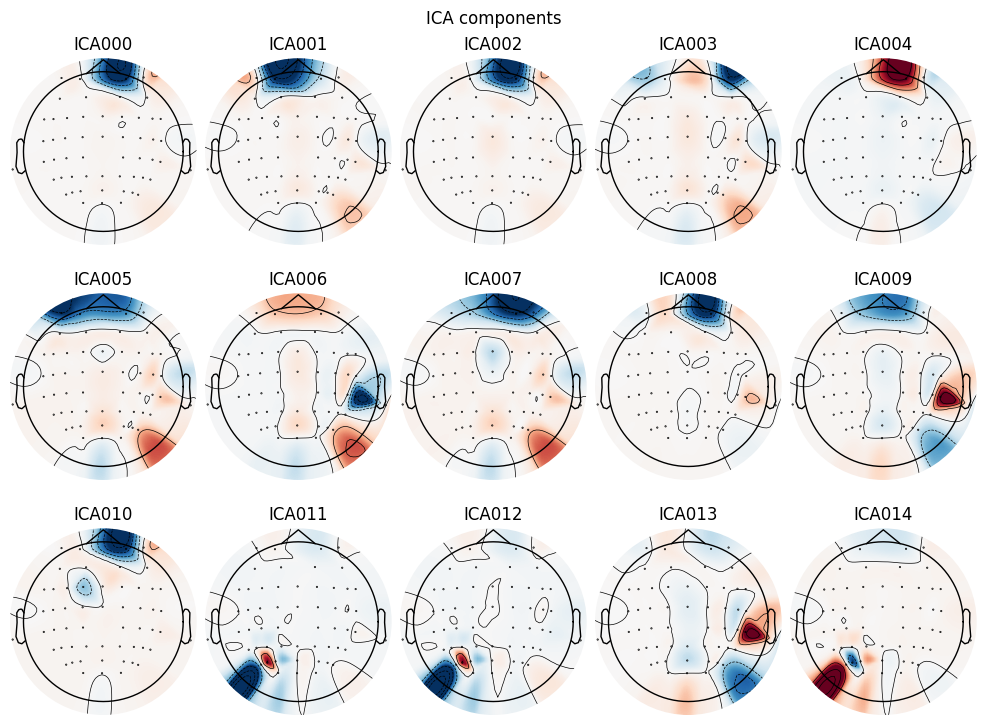

In [16]:
# Load
raw = mne.io.read_raw_edf(file_path, preload=True)

# Clean names
raw = clean_channel_names(raw)

# ✅ Set EOG type
if 'EOG' in raw.ch_names:
    raw.set_channel_types({'EOG': 'eog'})

# Set montage
raw.set_montage('standard_1020')

# Re-reference
raw.set_eeg_reference('average')

# Filter
raw.filter(0.1, 30)

# ICA
ica = mne.preprocessing.ICA(n_components=15, random_state=42)
ica.fit(raw)

ica.plot_components()

In [17]:
events, event_id = mne.events_from_annotations(raw)

print(event_id)

Used Annotations descriptions: ['Condition Baseline End  EpochE', 'Condition Baseline Start  EpochE', 'Condition Task_End  EpochE', 'Condition Task_Start  EpochE', 'Condition non target  EpochE', 'Condition target  EpochE', 'EventCode 1002  EpochE', 'EventCode 1003  EpochE', 'EventCode 1004  EpochE', 'EventCode 1005  EpochE', 'EventCode 1006  EpochE', 'EventCode 1007  EpochE', 'Impedance']
{'Condition Baseline End  EpochE': 1, 'Condition Baseline Start  EpochE': 2, 'Condition Task_End  EpochE': 3, 'Condition Task_Start  EpochE': 4, 'Condition non target  EpochE': 5, 'Condition target  EpochE': 6, 'EventCode 1002  EpochE': 7, 'EventCode 1003  EpochE': 8, 'EventCode 1004  EpochE': 9, 'EventCode 1005  EpochE': 10, 'EventCode 1006  EpochE': 11, 'EventCode 1007  EpochE': 12, 'Impedance': 13}


In [18]:
event_id_clean = {
    'Target': 6,
    'NonTarget': 5
}

In [19]:
epochs = mne.Epochs(
    raw,
    events,
    event_id=event_id_clean,
    tmin=-0.2,
    tmax=0.8,
    baseline=(None, 0),
    preload=True
)

Not setting metadata
75 matching events found
Setting baseline interval to [-0.2001953125, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 75 events and 1025 original time points ...
0 bad epochs dropped


In [20]:
print(epochs)

print("Target trials:", len(epochs['Target']))
print("NonTarget trials:", len(epochs['NonTarget']))

<Epochs | 75 events (all good), -0.2 – 0.8 s (baseline -0.2 – 0 s), ~32.9 MB, data loaded,
 'Target': 26
 'NonTarget': 49>
Target trials: 26
NonTarget trials: 49


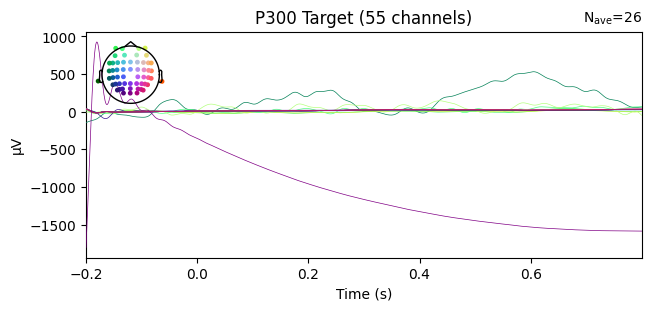

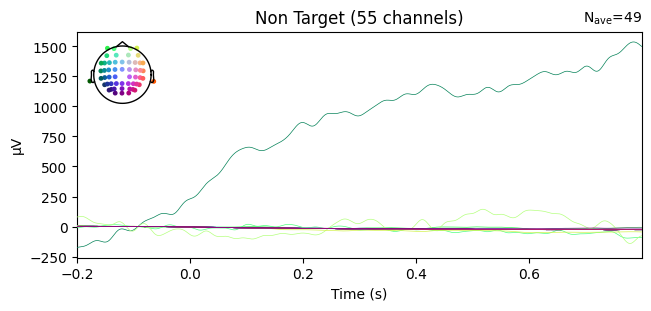

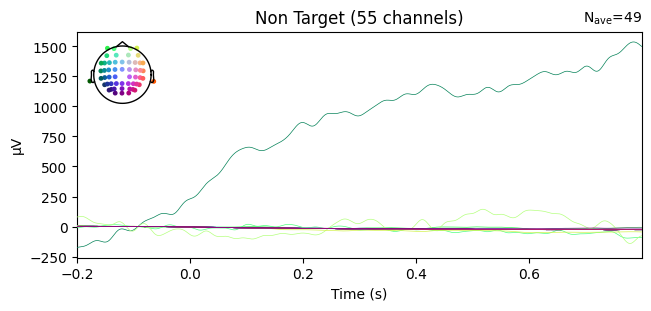

In [21]:
target_evoked = epochs['Target'].average()
nontarget_evoked = epochs['NonTarget'].average()

target_evoked.plot(titles="P300 Target")
nontarget_evoked.plot(titles="Non Target")

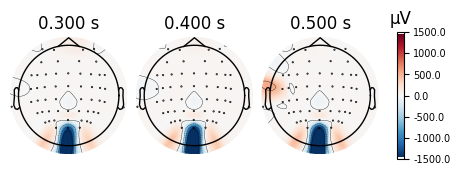

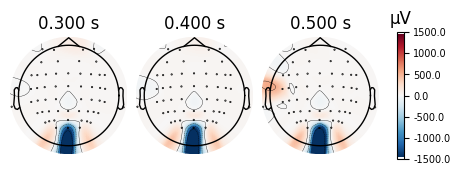

In [22]:
target_evoked.plot_topomap(times=[0.3, 0.4, 0.5])

In [23]:
def extract_features(epochs):
    data = epochs.get_data()
    sfreq = epochs.info['sfreq']
    
    features = []
    
    for trial in data:
        signal = trial.mean(axis=0)
        
        amp = np.max(signal)
        latency = np.argmax(signal) / sfreq
        
        features.append([amp, latency])
        
    return np.array(features)

X_target = extract_features(epochs['Target'])
X_nontarget = extract_features(epochs['NonTarget'])

In [24]:
y_target = np.ones(len(X_target))       # Target
y_nontarget = np.zeros(len(X_nontarget))  # NonTarget

X = np.vstack((X_target, X_nontarget))
y = np.concatenate((y_target, y_nontarget))

In [25]:
import numpy as np

def extract_features_and_label(epochs):
    data = epochs.get_data()
    sfreq = epochs.info['sfreq']
    
    X = []
    y = []
    
    # 🔥 Thresholds (you can tune later)
    threshold_amp = 5e-6
    threshold_latency = 0.35
    
    for trial in data:
        signal = trial.mean(axis=0)
        
        # Feature Extraction
        amp = np.max(signal)
        latency = np.argmax(signal) / sfreq
        
        # 🔥 Labeling (THIS IS YOUR MAIN STEP)
        if amp < threshold_amp or latency > threshold_latency:
            label = 1   # TBI
        else:
            label = 0   # Healthy
        
        X.append([amp, latency])
        y.append(label)
    
    return np.array(X), np.array(y)

In [26]:
X, y = extract_features_and_label(epochs['Target'])

print("Features shape:", X.shape)
print("Labels shape:", y.shape)

Features shape: (26, 2)
Labels shape: (26,)


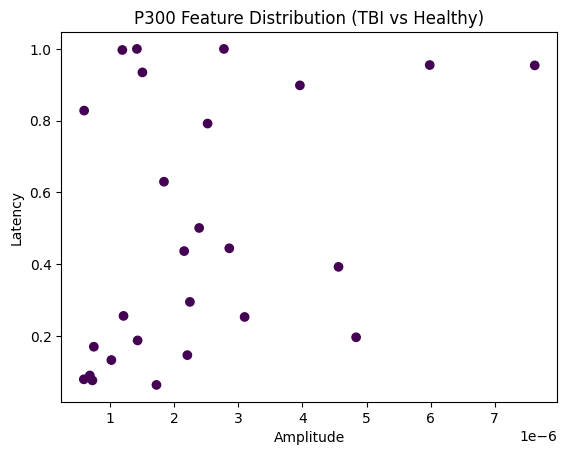

In [27]:
import matplotlib.pyplot as plt

plt.scatter(X[:,0], X[:,1], c=y)
plt.xlabel("Amplitude")
plt.ylabel("Latency")
plt.title("P300 Feature Distribution (TBI vs Healthy)")
plt.show()

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = SVC(kernel='rbf')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

ValueError: The number of classes has to be greater than one; got 1 class